## ECG ink removal - synthetic ink experiment

This notebook keeps the focus on **ink removal only**.

We start from a **clean ECG**.
We add **synthetic random ink**.
Then we run the same morphology pipeline.

### Why this setup
- no alignment problem
- no padding needed
- exact clean target is known
- exact synthetic ink mask is known

### Pipeline
1. Load one clean image.
2. Add synthetic ink.
3. Build a local background with blur + closing.
4. Build `blackhat`, `raw_mask`, and `refined_mask`.
5. Compare final outputs with MAE.

### Extra goal
Because the synthetic ink mask is known, we can also compare:
- `raw_mask` vs true ink mask
- `refined_mask` vs true ink mask

This helps explain why connected components may improve MAE.


In [79]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------
# Configuration
# ---------------------------------
base_path = Path("../../data/sample")
selected_ecg_id = "11842146"
clean_scan = "0001"

# Synthetic ink
RANDOM_SEED = None
N_STROKES = 15
N_BLOBS = 8
N_SMUDGES = 5

# Morphology pipeline
BLUR_KSIZE = 5
CLOSING_SHAPE = cv2.MORPH_ELLIPSE
CLOSING_KERNEL = 25
PERCENTILE = 89.4
MIN_THRESHOLD = 12
MIN_AREA = 40
MAX_AREA = 8000
MAX_ASPECT = 10.0
MIN_FILL = 0.12
DILATE_ITER = 1


## Helper functions

These functions keep the main steps short.
The notebook workflow itself stays step by step.


In [80]:
def load_gray_image(ecg_id, scan_type):
    path = base_path / ecg_id / f"{ecg_id}-{scan_type}.png"
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return img.astype(np.float32) / 255.0, path


def to_u8(img):
    return np.clip(np.round(img * 255.0), 0, 255).astype(np.uint8)


def masked_mae(a, b, mask):
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[mask] - b[mask])))


def mask_scores(pred_mask, true_mask):
    pred = pred_mask.astype(bool)
    true = true_mask.astype(bool)

    tp = int((pred & true).sum())
    fp = int((pred & ~true).sum())
    fn = int((~pred & true).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    iou = tp / max(tp + fp + fn, 1)

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "iou": iou,
    }


def generate_random_ink_from_clean(clean_img, seed=7, n_strokes=14, n_blobs=10, n_smudges=4):
    rng = np.random.default_rng(seed)
    h, w = clean_img.shape

    stroke_layer = np.zeros((h, w), dtype=np.float32)
    blob_layer = np.zeros((h, w), dtype=np.float32)
    smudge_layer = np.zeros((h, w), dtype=np.float32)

    # Dark thin strokes.
    for _ in range(n_strokes):
        x1 = int(rng.integers(0, w))
        y1 = int(rng.integers(0, h))
        length = int(rng.integers(min(h, w) // 30, min(h, w) // 8))
        angle = float(rng.uniform(0, 2 * np.pi))
        x2 = int(np.clip(x1 + length * np.cos(angle), 0, w - 1))
        y2 = int(np.clip(y1 + length * np.sin(angle), 0, h - 1))
        thickness = int(rng.integers(2, 8))
        value = float(rng.uniform(0.18, 0.45))
        cv2.line(stroke_layer, (x1, y1), (x2, y2), value, thickness, lineType=cv2.LINE_AA)

    # Compact blobs.
    for _ in range(n_blobs):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(4, w // 80), max(8, w // 25))),
            int(rng.integers(max(4, h // 80), max(8, h // 25))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.10, 0.6))
        cv2.ellipse(blob_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    # Broad faint smudges.
    for _ in range(n_smudges):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(20, w // 25), max(40, w // 10))),
            int(rng.integers(max(20, h // 25), max(40, h // 10))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.03, 0.5))
        cv2.ellipse(smudge_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    blob_layer = cv2.GaussianBlur(blob_layer, (0, 0), sigmaX=3, sigmaY=3)
    smudge_layer = cv2.GaussianBlur(smudge_layer, (0, 0), sigmaX=11, sigmaY=11)

    darkening = np.clip(stroke_layer + blob_layer + smudge_layer, 0.0, 0.99)
    synthetic_ink = np.clip(clean_img - darkening, 0.0, 1.0)

    # This is the exact synthetic artifact mask.
    true_ink_mask = darkening > 0.03
    return synthetic_ink, darkening, true_ink_mask


## Step 1 - Load one clean image

We load only the clean ECG.
No pad is needed in this notebook.


ECG ID: 11842146
clean path: ..\..\data\sample\11842146\11842146-0001.png
clean shape: (1700, 2200)


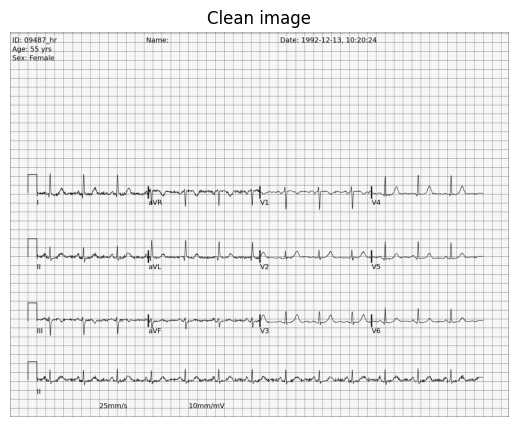

In [81]:
clean_img, clean_path = load_gray_image(selected_ecg_id, clean_scan)
full_mask = np.ones_like(clean_img, dtype=bool)

print("ECG ID:", selected_ecg_id)
print("clean path:", clean_path)
print("clean shape:", clean_img.shape)

plt.figure(figsize=(12, 5))
plt.imshow(clean_img, cmap="gray")
plt.title("Clean image")
plt.axis("off")
plt.show()


## Step 2 - Add synthetic random ink

Now we create random dark artifacts from the clean image.

We keep:
- the synthetic ink image
- the darkening map
- the true synthetic ink mask

Because the mask is known exactly, we can later compare it with `raw_mask` and `refined_mask`.


Random seed: None
Synthetic ink MAE  on all clean image mask before processing: 0.019096
Synthetic ink MAE  on all clean image mask before processing: 0.186353
True synthetic mask pixels: 377743


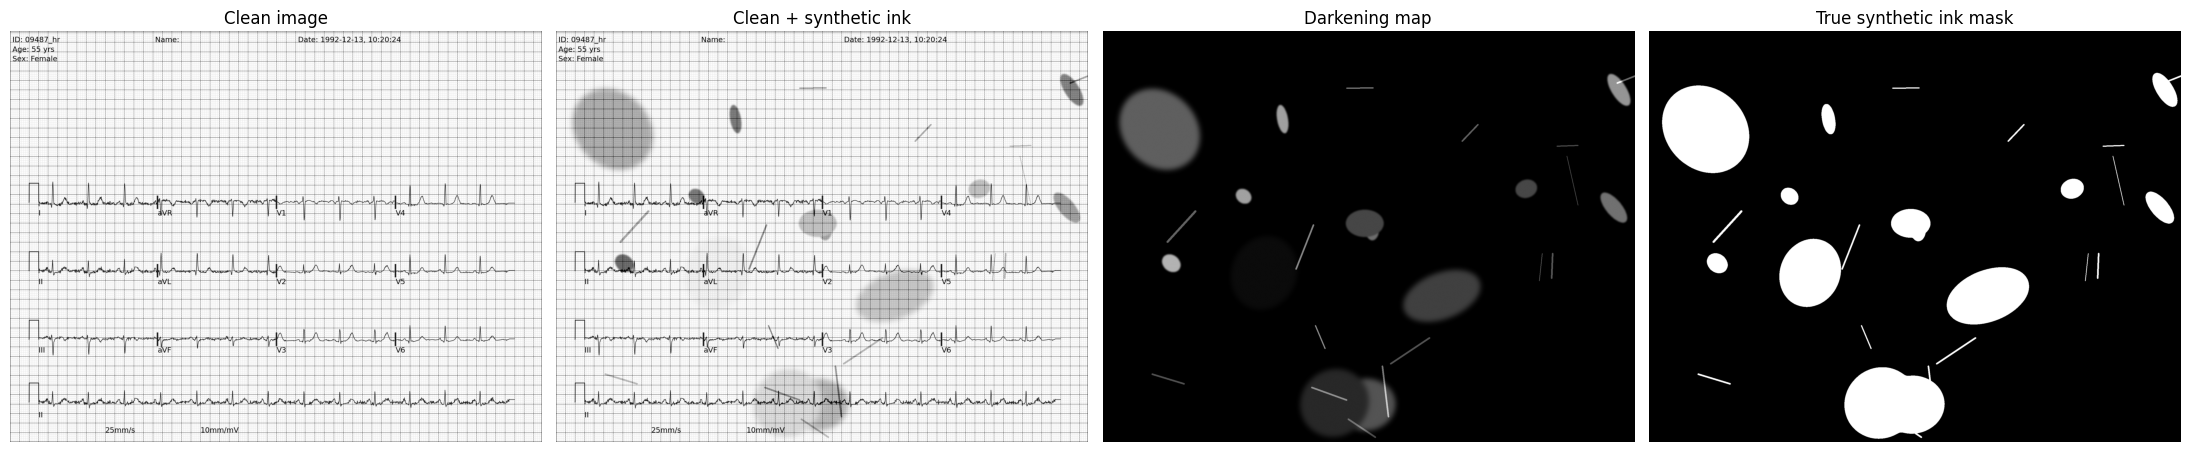

In [82]:
synthetic_ink, darkening_map, true_ink_mask = generate_random_ink_from_clean(
    clean_img,
    seed=RANDOM_SEED,
    n_strokes=N_STROKES,
    n_blobs=N_BLOBS,
    n_smudges=N_SMUDGES,
)

mae_before_all = masked_mae(synthetic_ink, clean_img, full_mask)
mae_before_ink_mask = masked_mae(synthetic_ink, clean_img, true_ink_mask)

print("Random seed:", RANDOM_SEED)
print(f"Synthetic ink MAE  on all clean image mask before processing: {mae_before_all:.6f}")
print(f"Synthetic ink MAE  on all clean image mask before processing: {mae_before_ink_mask:.6f}")
print("True synthetic mask pixels:", int(true_ink_mask.sum()))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(clean_img, cmap="gray")
axes[0].set_title("Clean image")
axes[0].axis("off")
axes[1].imshow(synthetic_ink, cmap="gray")
axes[1].set_title("Clean + synthetic ink")
axes[1].axis("off")
axes[2].imshow(darkening_map, cmap="gray")
axes[2].set_title("Darkening map")
axes[2].axis("off")
axes[3].imshow(true_ink_mask, cmap="gray")
axes[3].set_title("True synthetic ink mask")
axes[3].axis("off")
plt.tight_layout()
plt.show()


## Step 3 - Build the local background

This step has two parts:
- Gaussian blur
- morphological closing

The closing gives a brighter local background.
Dark defects tend to be filled.


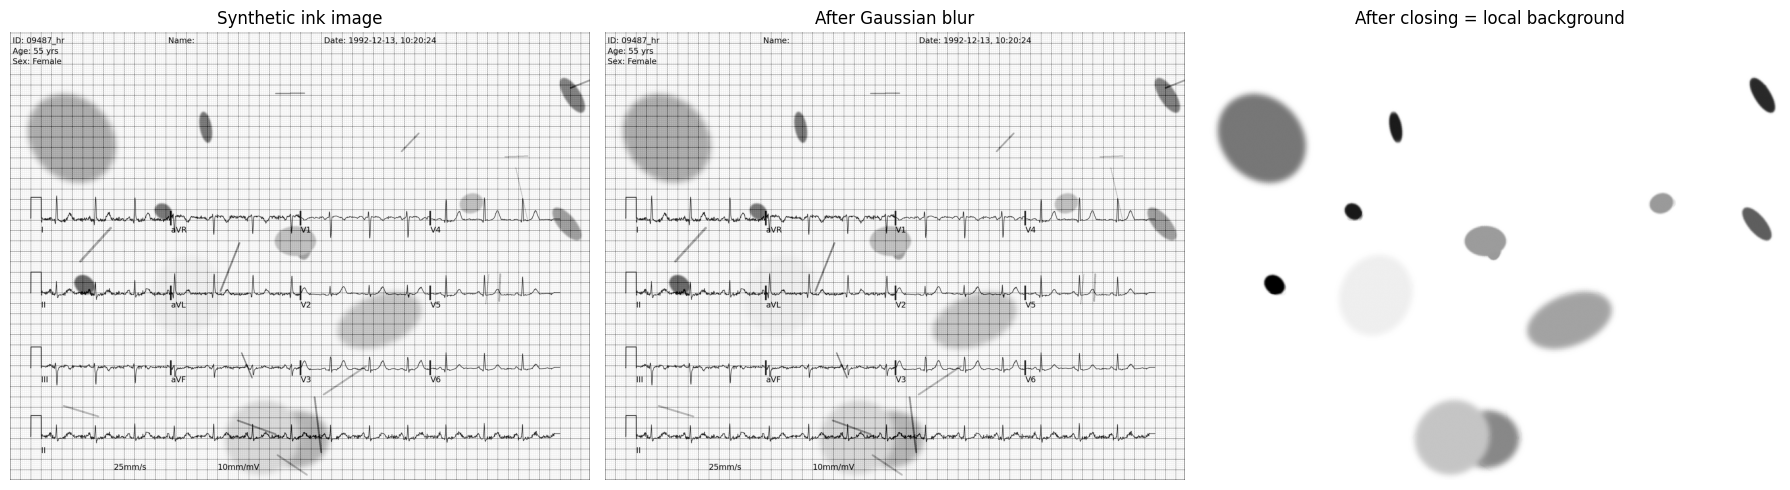

In [83]:
ink_u8 = to_u8(synthetic_ink)

blurred_u8 = cv2.GaussianBlur(ink_u8, (BLUR_KSIZE, BLUR_KSIZE), 0)
blurred_u8=ink_u8
kernel = cv2.getStructuringElement(CLOSING_SHAPE, (CLOSING_KERNEL, CLOSING_KERNEL))
background_u8 = cv2.morphologyEx(blurred_u8, cv2.MORPH_CLOSE, kernel)

blurred = blurred_u8.astype(np.float32) / 255.0
background = background_u8.astype(np.float32) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(synthetic_ink, cmap="gray")
axes[0].set_title("Synthetic ink image")
axes[0].axis("off")
axes[1].imshow(blurred, cmap="gray")
axes[1].set_title("After Gaussian blur")
axes[1].axis("off")
axes[2].imshow(background, cmap="gray")
axes[2].set_title("After closing = local background")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## Step 4 - Build the artifact masks

Now we compute:
- `blackhat`
- `raw_mask`
- `refined_mask`

Because the true synthetic mask is known, we can score both masks.


black-hat threshold: 36
raw mask pixels    : 559365
refined mask pixels: 1036

Raw mask scores
  precision: 0.1132
  recall   : 0.1677
  IoU      : 0.0725

Refined mask scores
  precision: 0.6226
  recall   : 0.0017
  IoU      : 0.0017


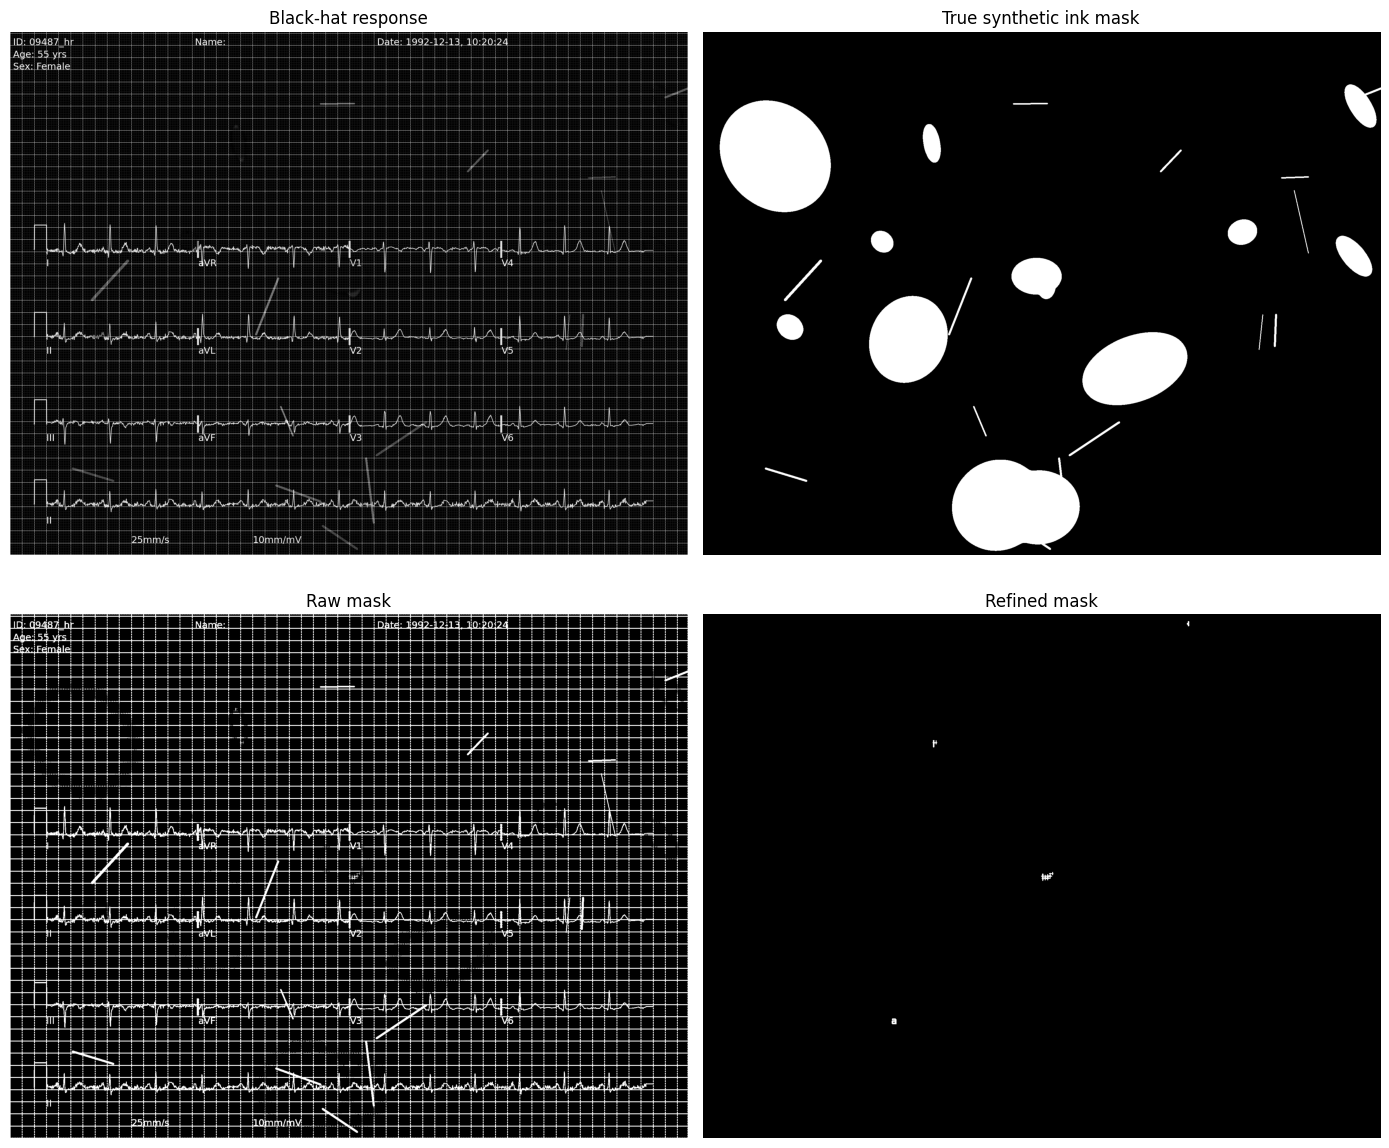

In [84]:
blackhat_u8 = cv2.subtract(background_u8, blurred_u8)
blackhat = blackhat_u8.astype(np.float32) / 255.0

valid_values = blackhat_u8[full_mask]
threshold = max(MIN_THRESHOLD, int(np.percentile(valid_values, PERCENTILE)))
raw_mask = ((blackhat_u8 >= threshold) & full_mask).astype(np.uint8)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(raw_mask, connectivity=8)
refined_mask = np.zeros_like(raw_mask)

for label in range(1, num_labels):
    area = int(stats[label, cv2.CC_STAT_AREA])
    if area < MIN_AREA or area > MAX_AREA:
        continue

    width = int(stats[label, cv2.CC_STAT_WIDTH])
    height = int(stats[label, cv2.CC_STAT_HEIGHT])
    bbox_area = max(width * height, 1)

    aspect = max(width, height) / max(1, min(width, height))
    fill = area / bbox_area

    if aspect > MAX_ASPECT:
        continue
    if fill < MIN_FILL:
        continue

    refined_mask[labels == label] = 1

if DILATE_ITER > 0:
    refined_mask = cv2.dilate(refined_mask, np.ones((3, 3), dtype=np.uint8), iterations=DILATE_ITER)

raw_mask_bool = raw_mask.astype(bool)
refined_mask_bool = refined_mask.astype(bool)

raw_scores = mask_scores(raw_mask_bool, true_ink_mask)
refined_scores = mask_scores(refined_mask_bool, true_ink_mask)

print("black-hat threshold:", threshold)
print("raw mask pixels    :", int(raw_mask_bool.sum()))
print("refined mask pixels:", int(refined_mask_bool.sum()))
print()
print("Raw mask scores")
print(f"  precision: {raw_scores['precision']:.4f}")
print(f"  recall   : {raw_scores['recall']:.4f}")
print(f"  IoU      : {raw_scores['iou']:.4f}")
print()
print("Refined mask scores")
print(f"  precision: {refined_scores['precision']:.4f}")
print(f"  recall   : {refined_scores['recall']:.4f}")
print(f"  IoU      : {refined_scores['iou']:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes[0, 0].imshow(blackhat, cmap="gray")
axes[0, 0].set_title("Black-hat response")
axes[0, 0].axis("off")
axes[0, 1].imshow(true_ink_mask, cmap="gray")
axes[0, 1].set_title("True synthetic ink mask")
axes[0, 1].axis("off")
axes[1, 0].imshow(raw_mask_bool, cmap="gray")
axes[1, 0].set_title("Raw mask")
axes[1, 0].axis("off")
axes[1, 1].imshow(refined_mask_bool, cmap="gray")
axes[1, 1].set_title("Refined mask")
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()


## Step 5 - Compare final outputs

Here we compare several outputs:
- original synthetic ink image
- `blackhat_inv`
- raw-mask replacement
- refined-mask replacement

This helps us see which final representation gives the best MAE.


MAE before synthetic corruption : 0.019096
MAE after blackhat_inv         : 0.001452
MAE after raw replacement      : 0.075513
MAE after refined replacement  : 0.019120


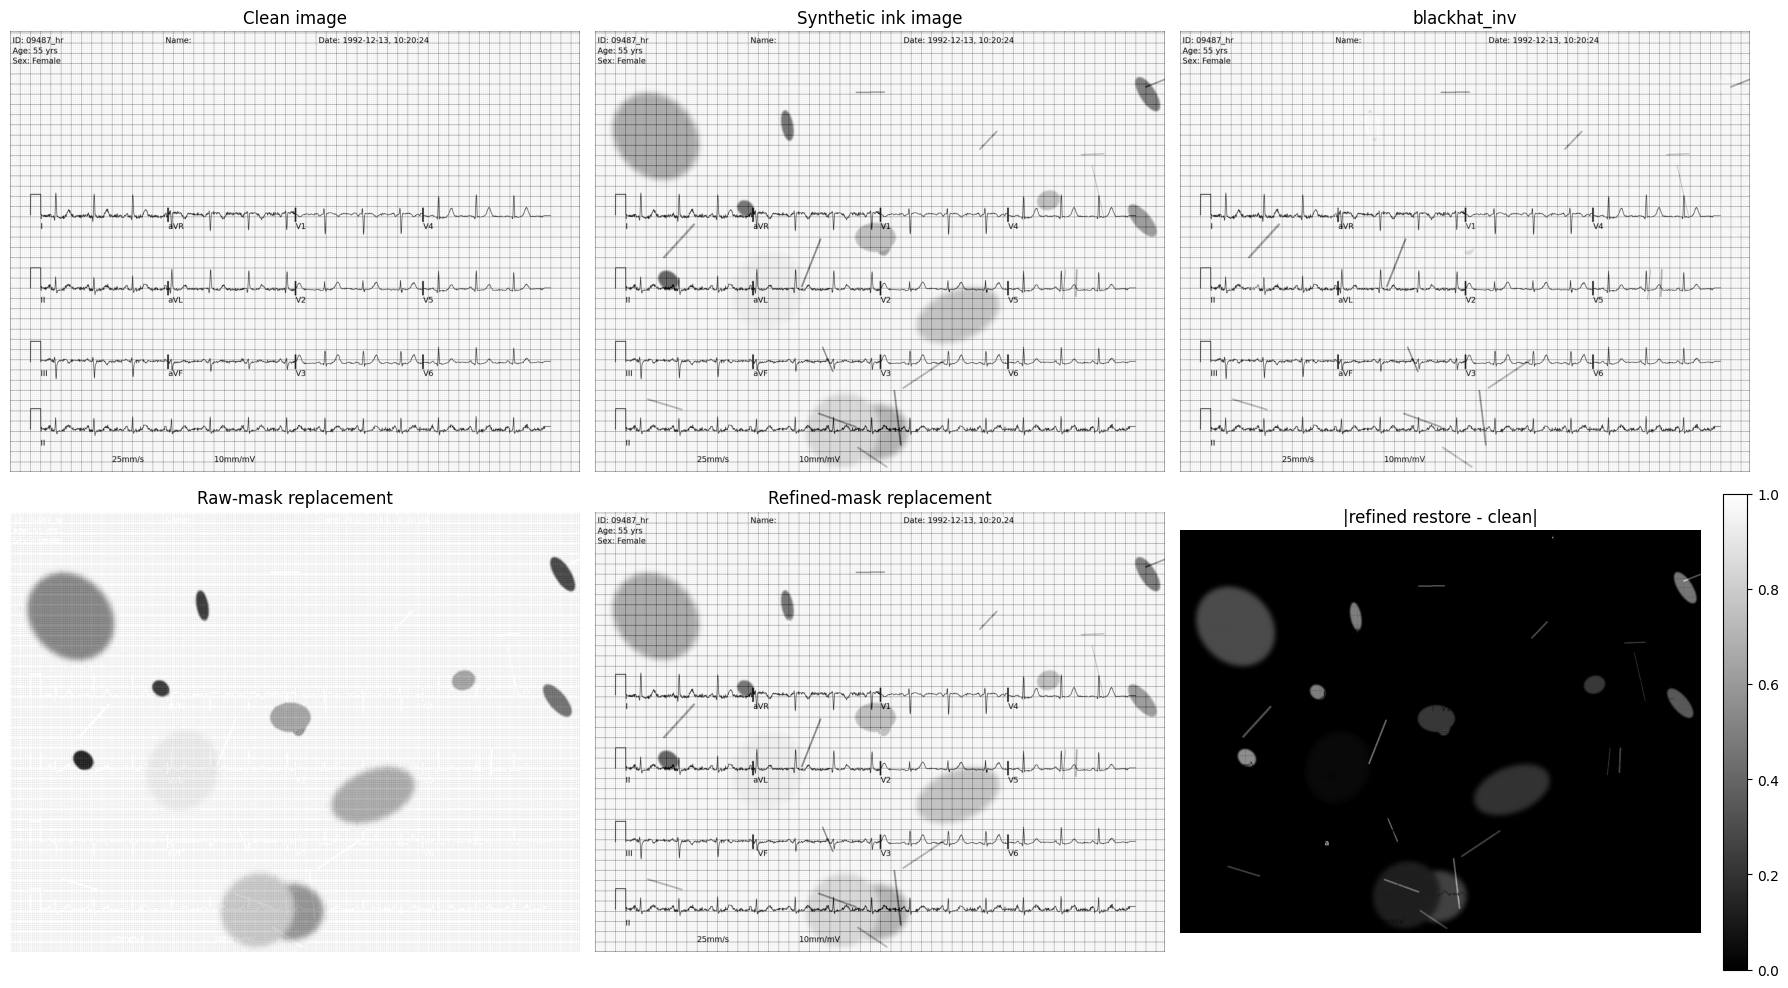

In [85]:
blackhat_inv = 1.0 - (blackhat_u8.astype(np.float32) / 255.0)

raw_restore = synthetic_ink.copy()
raw_restore[raw_mask_bool] = background[raw_mask_bool]

refined_restore = synthetic_ink.copy()
refined_restore[refined_mask_bool] = background[refined_mask_bool]

mae_before = masked_mae(synthetic_ink, clean_img, full_mask)
mae_blackhat_inv = masked_mae(blackhat_inv, clean_img, full_mask)
mae_raw_restore = masked_mae(raw_restore, clean_img, full_mask)
mae_refined_restore = masked_mae(refined_restore, clean_img, full_mask)

err_refined = np.abs(refined_restore - clean_img)

print(f"MAE before synthetic corruption : {mae_before:.6f}")
print(f"MAE after blackhat_inv         : {mae_blackhat_inv:.6f}")
print(f"MAE after raw replacement      : {mae_raw_restore:.6f}")
print(f"MAE after refined replacement  : {mae_refined_restore:.6f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(clean_img, cmap="gray")
axes[0, 0].set_title("Clean image")
axes[0, 0].axis("off")
axes[0, 1].imshow(synthetic_ink, cmap="gray")
axes[0, 1].set_title("Synthetic ink image")
axes[0, 1].axis("off")
axes[0, 2].imshow(blackhat_inv, cmap="gray")
axes[0, 2].set_title("blackhat_inv")
axes[0, 2].axis("off")
axes[1, 0].imshow(raw_restore, cmap="gray")
axes[1, 0].set_title("Raw-mask replacement")
axes[1, 0].axis("off")
axes[1, 1].imshow(refined_restore, cmap="gray")
axes[1, 1].set_title("Refined-mask replacement")
axes[1, 1].axis("off")
im = axes[1, 2].imshow(err_refined, cmap="gray")
axes[1, 2].set_title("|refined restore - clean|")
axes[1, 2].axis("off")
plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [86]:
candidates = {
    "synthetic_ink": synthetic_ink,
    "blackhat_inv": blackhat_inv,
    "raw_restore": raw_restore,
    "refined_restore": refined_restore,
}

for name, img in candidates.items():
    print(name)
    print("  MAE on true ink mask :", masked_mae(img, clean_img, true_ink_mask))
    print("  MAE outside ink mask :", masked_mae(img, clean_img, ~true_ink_mask))


synthetic_ink
  MAE on true ink mask : 0.18635301291942596
  MAE outside ink mask : 0.00030463404254987836
blackhat_inv
  MAE on true ink mask : 0.01397218368947506
  MAE outside ink mask : 4.492592051974498e-05
raw_restore
  MAE on true ink mask : 0.19986112415790558
  MAE outside ink mask : 0.061542969197034836
refined_restore
  MAE on true ink mask : 0.18615832924842834
  MAE outside ink mask : 0.0003533266135491431


## Conclusion

Saved result on `11842146`:
- before processing: all-pixel MAE `0.019096`, ink-mask MAE `0.186353`
- `blackhat_inv`: all-pixel MAE `0.001452`, ink-mask MAE `0.013972`, outside-mask MAE `0.000045`
- `raw_restore`: all-pixel MAE `0.075513`
- `refined_restore`: all-pixel MAE `0.019120`

`blackhat_inv` is clearly the best result in this notebook.
It improves both the ink region and the outside region.
For this synthetic case, direct black-hat restoration is the strongest classical method tested so far.
